<a href="https://colab.research.google.com/github/iym24004/A03-Sampling-iym24004/blob/main/A03_SamplingxAI_5512.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A03: Sampling
-------------
**Dr. Dave Wanik - Operations and Information Management - University of Connecticut**

For this assignment, I'd like you to apply the topics of  undersampling, oversampling and SMOTE to a toy dataset to see if you get better performance by using these sampling methods. In my experience, sampling helps sometimes but not all times.

# **Parvathi Meghanath**

# Data


In [19]:
import pandas as pd
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

In [20]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


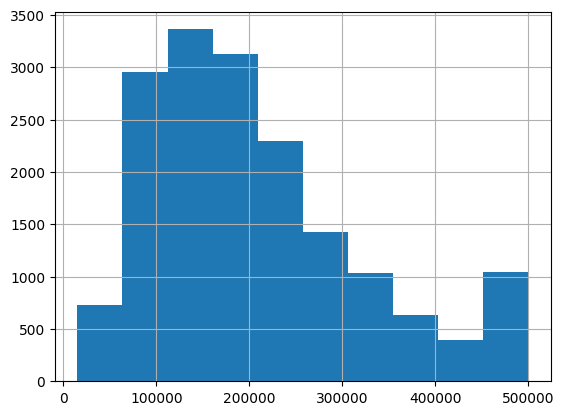

In [21]:
import matplotlib.pyplot as plt

df['median_house_value'].hist()
plt.show()

In [22]:
# create a new target variable for SMOTE
import numpy as np

# nice imbalanced data!
df['median_house_value'] = np.where(df['median_house_value'] < 380000, 1, 0)
df['median_house_value'].value_counts()

,count
median_house_value,
1,15304
0,1696


# Split data into train and test

In [23]:
from collections import Counter
from sklearn.model_selection import train_test_split

# target: 1 = house under $380k, 0 = house $380k or more
y = df['median_house_value']
X = df.drop('median_house_value', axis=1)
print(X.shape, y.shape)

# split FIRST - stratify=y keeps the original 0/1 ratio in the test set
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=123)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

print('Train:', Counter(y_train))
print('Test: ', Counter(y_test))   # test stays untouched - real rows only
# note: 0 is the MINORITY class, 1 is the MAJORITY class

(17000, 8) (17000,)
(13600, 8) (3400, 8)
(13600,) (3400,)
Train: Counter({1: 12243, 0: 1357})
Test:  Counter({1: 3061, 0: 339})


# Majority Undersampling

In [24]:
# use imblearn to perform majority undersampling on X_train, evaluate on test partition

In [26]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

def evaluate(X_sampled, y_sampled, title):
    print(f"\n--- {title} ---")
    # Train the model on the sampled data
    model = DecisionTreeClassifier(min_samples_split=10, random_state=123)
    model.fit(X_sampled, y_sampled)

    # Evaluate on the original, untouched test set
    y_pred = model.predict(X_test) # X_test, y_test are global variables from an earlier cell

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    return y_pred

undersample = RandomUnderSampler(sampling_strategy='majority', random_state=123)
X_under, y_under = undersample.fit_resample(X_train, y_train)   # TRAIN only!
print('Before:', Counter(y_train))
print('After: ', Counter(y_under))

under_preds = evaluate(X_under, y_under, 'Majority Undersampling')

Before: Counter({1: 12243, 0: 1357})
After:  Counter({0: 1357, 1: 1357})

--- Majority Undersampling ---
Confusion Matrix:
[[ 280   59]
 [ 577 2484]]

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.83      0.47       339
           1       0.98      0.81      0.89      3061

    accuracy                           0.81      3400
   macro avg       0.65      0.82      0.68      3400
weighted avg       0.91      0.81      0.84      3400



*   Majority undersampling balanced the classes by reducing the majority class in the training set to 1,357 rows.
*   The model detected the minority class much better (recall = 0.83), catching 280 of the 339 expensive houses.
*   However, precision was very low (0.33), so many majority samples were wrongly predicted as minority (577 false positives).
*   Overall accuracy dropped a lot (from 0.92 to 0.81) because removing so many majority samples caused a big loss of information.

# Minority Oversampling


In [27]:
# use imblearn to perform minority oversampling on X_train, evaluate on test partition
from imblearn.over_sampling import RandomOverSampler

oversample = RandomOverSampler(sampling_strategy='minority', random_state=123)
X_over, y_over = oversample.fit_resample(X_train, y_train)   # TRAIN only!
print('Before:', Counter(y_train))
print('After: ', Counter(y_over))

over_preds = evaluate(X_over, y_over, 'Minority Oversampling')

Before: Counter({1: 12243, 0: 1357})
After:  Counter({0: 12243, 1: 12243})

--- Minority Oversampling ---
Confusion Matrix:
[[ 190  149]
 [ 119 2942]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.56      0.59       339
           1       0.95      0.96      0.96      3061

    accuracy                           0.92      3400
   macro avg       0.78      0.76      0.77      3400
weighted avg       0.92      0.92      0.92      3400



*   Minority oversampling balanced the classes by duplicating minority rows until both classes had 12,243 rows.
*   Train scores were perfect (1.00), which means the tree memorized the copied rows (overfitting).
*   On the test set, recall for the minority class actually dropped a little (0.56 compared to 0.60 in the baseline), while precision went up slightly (0.61).
*   Accuracy stayed the same (0.92), so oversampling did not really help because copied rows add no new information.

# SMOTE

In [28]:
# use imblearn to perform synthetic minority data on X_train, evaluate on test partition
from imblearn.over_sampling import SMOTE

smote = SMOTE(k_neighbors=5, random_state=123)
X_res, y_res = smote.fit_resample(X_train, y_train)   # TRAIN only!
print('Before:', Counter(y_train))
print('After: ', Counter(y_res))

smote_preds = evaluate(X_res, y_res, 'SMOTE')

Before: Counter({1: 12243, 0: 1357})
After:  Counter({0: 12243, 1: 12243})

--- SMOTE ---
Confusion Matrix:
[[ 257   82]
 [ 254 2807]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.76      0.60       339
           1       0.97      0.92      0.94      3061

    accuracy                           0.90      3400
   macro avg       0.74      0.84      0.77      3400
weighted avg       0.92      0.90      0.91      3400



*   SMOTE balanced the classes by creating new synthetic minority rows instead of copying existing ones.
*   Recall for the minority class improved to 0.76, catching 257 of the 339 expensive houses.
*   Precision was 0.50, with 254 false positives, which is much better than undersampling.
*   SMOTE had the best minority F1-score (0.60), and accuracy stayed high (0.90).

# Comparison of 3 methods


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []
for name, preds in [('Undersampling', under_preds),
                    ('Oversampling', over_preds),
                    ('SMOTE', smote_preds)]:
    results.append([name,
                    accuracy_score(y_test, preds),
                    precision_score(y_test, preds, pos_label=0),   # minority class = 0
                    recall_score(y_test, preds, pos_label=0),
                    f1_score(y_test, preds, pos_label=0)])

compare_df = pd.DataFrame(results, columns=['method', 'accuracy', 'precision_0',
                                            'recall_0', 'f1_0'])
compare_df.round(3)

,method,accuracy,precision_0,recall_0,f1_0
0,Undersampling,0.813,0.327,0.826,0.468
1,Oversampling,0.921,0.615,0.560,0.586
2,SMOTE,0.901,0.503,0.758,0.605


*   SMOTE performed best overall, with the highest minority F1-score (0.605), good recall (0.758), and high accuracy (0.901).
*   Undersampling had the highest recall (0.826), so it caught the most minority cases, but it had the worst precision (0.327) and F1-score (0.468), meaning many wrong minority predictions.
*   Oversampling had the highest accuracy (0.921) and precision (0.615), but the lowest recall (0.560), so it missed many minority cases.
*   Accuracy is not the best way to compare these methods because the data is imbalanced, so the minority F1-score is a better measure.
*   The difference between SMOTE and oversampling is small (0.605 vs 0.586), which shows that sampling helps sometimes but not always.


# Reproducibility - run it 30 times or more!



         accuracy   precision      recall
count  100.000000  100.000000  100.000000
mean     0.891474    0.471456    0.721180
std      0.005562    0.017815    0.025495
min      0.875882    0.423853    0.657817
25%      0.887059    0.457596    0.702065
50%      0.891471    0.471208    0.721239
75%      0.895000    0.482971    0.734513
max      0.903529    0.511482    0.784661


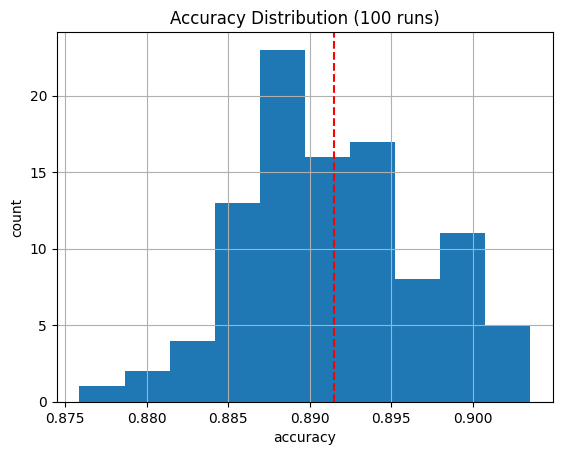

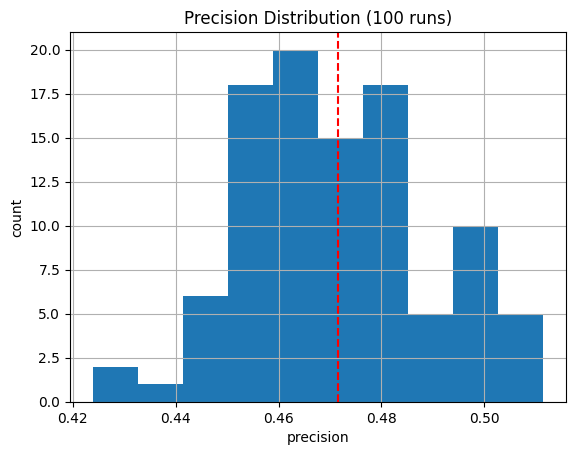

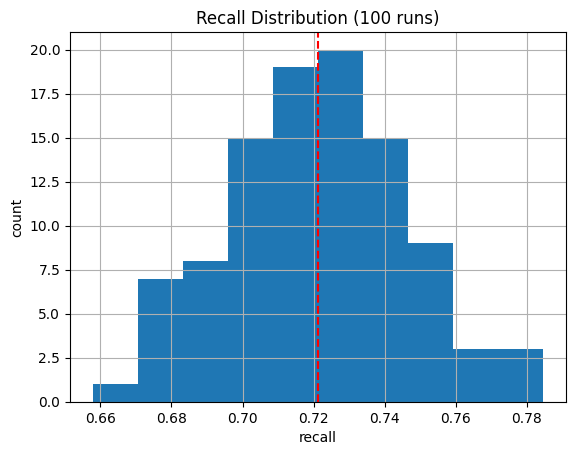

Best runs by recall:
    run  accuracy  precision    recall
50   50  0.892353   0.475850  0.784661
24   24  0.890294   0.469858  0.781711
40   40  0.894118   0.480804  0.775811

Worst runs by recall:
    run  accuracy  precision    recall
28   28  0.892353   0.471459  0.657817
83   83  0.884412   0.447059  0.672566
22   22  0.889412   0.462626  0.675516


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt

results = []

for i in range(100):

    # split each time with a different random_state
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=i)

    # apply SMOTE on training data only
    smote = SMOTE(random_state=i)
    X_tr_smote, y_tr_smote = smote.fit_resample(X_tr, y_tr)

    # train the model (same model as the rest of the notebook)
    model = DecisionTreeClassifier(min_samples_split=10, random_state=i)
    model.fit(X_tr_smote, y_tr_smote)

    # evaluate on the real test set
    preds = model.predict(X_te)

    # store metrics (pos_label=0 because class 0 is the minority class)
    results.append([
        i,
        accuracy_score(y_te, preds),
        precision_score(y_te, preds, pos_label=0, zero_division=0),
        recall_score(y_te, preds, pos_label=0, zero_division=0)
    ])

# create dataframe
results_df = pd.DataFrame(results, columns=["run", "accuracy", "precision", "recall"])
print(results_df[["accuracy", "precision", "recall"]].describe())

# plot distributions
for metric in ["accuracy", "precision", "recall"]:
    results_df[metric].hist()
    plt.axvline(results_df[metric].mean(), color="red", linestyle="--")
    plt.title(metric.capitalize() + " Distribution (100 runs)")
    plt.xlabel(metric)
    plt.ylabel("count")
    plt.show()

# best and worst splits
print("Best runs by recall:")
print(results_df.sort_values("recall", ascending=False).head(3))
print("\nWorst runs by recall:")
print(results_df.sort_values("recall").head(3))

# Comments on the repeated experiment

*   I repeated SMOTE 100 times, with a different train/test split each time.
*   Accuracy was very stable (0.876 to 0.904), while precision (0.424 to 0.511) and recall (0.658 to 0.785) changed more.
*   For all three metrics, the mean and median were almost the same, so the distributions were fairly close to a bell curve.
*   Some splits did much better than others: the best run had recall of 0.785 and the worst had 0.658, even though only the split changed.
*   My first SMOTE split (recall 0.758, precision 0.503) was better than the 100-run average (recall 0.721, precision 0.471), so it was a lucky split.
*   This shows that one split is not enough, and it's better to look at the average over many runs.